# Rotary Spectrum function Testing  

**Purpose**: Code for testing the rotary spectrum functions on fake data

**Luke Colosi | lcolosi@ucsd.edu**

Force matplotlib plots to display directly within the output cell of the notebook: 

In [1]:
%matplotlib inline


Import python libraries


In [2]:
import numpy as np
import matplotlib.pyplot as plt
import sys
import cmocean.cm as cmo

# Set path to access python functions
sys.path.append('/Users/lukecolosi/Desktop/projects/graduate_research/Gille_lab/AirSeaCoupling/tools/')

#--- Luke's Python Functions ---# 
from spectra import rotary_spectrum_welch

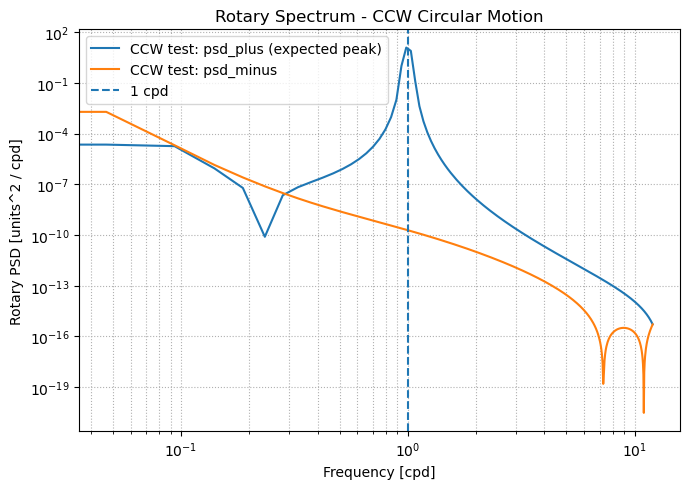

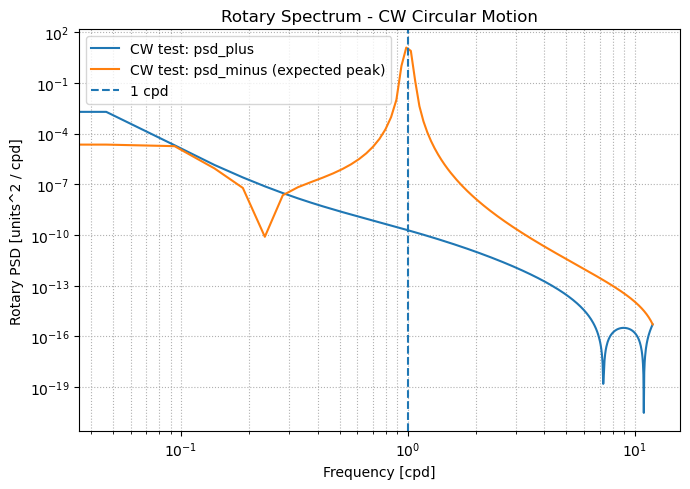

CCW test:
  Peak in psd_plus  ~ 0.984 cpd
  Peak in psd_minus ~ 0.000 cpd

CW test:
  Peak in psd_plus  ~ 0.000 cpd
  Peak in psd_minus ~ 0.984 cpd


In [3]:
# --------------------------------------------------------------------------
# Synthetic test: pure circular motions at 1 cpd
# --------------------------------------------------------------------------

# Sampling parameters
dt = 3600.0          # sampling interval [s] = 1 hour
N = 4096             # number of samples
t = np.arange(N) * dt

# Target frequency
f0_cpd = 1.0                          # 1 cycle per day
omega0 = 2.0 * np.pi * f0_cpd / 86400.0   # rad/s

# Amplitude
U0 = 1.0

# CCW circular motion:
# u = U cos(ωt), v = U sin(ωt) -> z = u + i v = U e^{i ω t} (CCW rotation)
u_ccw = U0 * np.cos(omega0 * t)
v_ccw = U0 * np.sin(omega0 * t)

# CW circular motion:
# u = U cos(ωt), v = -U sin(ωt) -> z = U e^{-i ω t} (CW rotation)
u_cw = U0 * np.cos(omega0 * t)
v_cw = -U0 * np.sin(omega0 * t)

# Choose number of windows
M = 8

# --------------------------------------------------------------------------
# Compute rotary spectra in cycles per day (cpd)
# --------------------------------------------------------------------------

psd_plus_ccw, psd_minus_ccw, f_cpd, CIp_ccw, CIm_ccw, var_ccw = rotary_spectrum_welch(
    u_ccw, v_ccw, dt, M, units='cpd'
)

psd_plus_cw, psd_minus_cw, f_cpd2, CIp_cw, CIm_cw, var_cw = rotary_spectrum_welch(
    u_cw, v_cw, dt, M, units='cpd'
)

# --------------------------------------------------------------------------
# Plot CCW test
# --------------------------------------------------------------------------

plt.figure(figsize=(7, 5))
plt.loglog(f_cpd, psd_plus_ccw, label='CCW test: psd_plus (expected peak)')
plt.loglog(f_cpd, psd_minus_ccw, label='CCW test: psd_minus')
plt.axvline(f0_cpd, linestyle='--', label='1 cpd')
plt.xlabel('Frequency [cpd]')
plt.ylabel('Rotary PSD [units^2 / cpd]')
plt.title('Rotary Spectrum - CCW Circular Motion')
plt.legend()
plt.grid(True, which='both', linestyle=':')
plt.tight_layout()

# --------------------------------------------------------------------------
# Plot CW test
# --------------------------------------------------------------------------

plt.figure(figsize=(7, 5))
plt.loglog(f_cpd2, psd_plus_cw, label='CW test: psd_plus')
plt.loglog(f_cpd2, psd_minus_cw, label='CW test: psd_minus (expected peak)')
plt.axvline(f0_cpd, linestyle='--', label='1 cpd')
plt.xlabel('Frequency [cpd]')
plt.ylabel('Rotary PSD [units^2 / cpd]')
plt.title('Rotary Spectrum - CW Circular Motion')
plt.legend()
plt.grid(True, which='both', linestyle=':')
plt.tight_layout()

plt.show()

# --------------------------------------------------------------------------
# Print peak frequencies
# --------------------------------------------------------------------------

i_peak_plus_ccw = np.argmax(psd_plus_ccw)
i_peak_minus_ccw = np.argmax(psd_minus_ccw)

i_peak_plus_cw = np.argmax(psd_plus_cw)
i_peak_minus_cw = np.argmax(psd_minus_cw)

print("CCW test:")
print(f"  Peak in psd_plus  ~ {f_cpd[i_peak_plus_ccw]:.3f} cpd")
print(f"  Peak in psd_minus ~ {f_cpd[i_peak_minus_ccw]:.3f} cpd")

print("\nCW test:")
print(f"  Peak in psd_plus  ~ {f_cpd2[i_peak_plus_cw]:.3f} cpd")
print(f"  Peak in psd_minus ~ {f_cpd2[i_peak_minus_cw]:.3f} cpd")


In [4]:
var_ccw

{'time': array([1.00009385, 1.00009385, 1.00009385, 1.00009385, 1.00009385,
        1.00009385, 1.00009385, 1.00009385, 1.00009385, 1.00009385,
        1.00009385, 1.00009385, 1.00009385, 1.00009385, 1.00009385]),
 'freq_plus': np.float64(1.0001141046734516),
 'freq_minus': np.float64(0.00020412186944614668)}